<a href="https://colab.research.google.com/github/NethmiKaveeshaE23174/Statistical-Learning-e23174/blob/main/assignment_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gaussian Process Regression

Consider the following [data set](https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset) that has been created in an energy analysis using 12 different building shapes simulated in Ecotect. The buildings differ with respect to the glazing area, the glazing area distribution, and the orientation, amongst other parameters. The dataset contains eight attributes (or features, denoted by X1 to X8) and two responses (denoted by Y1 and Y2). Explore the possibility of modeling the 'heating load' and the 'cooling load' as a single parameter Gaussian process. Discuss your conclusions.

In [2]:
import kagglehub

# Download latest version
kagglepath="elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


In [4]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/ENB2012_data.csv")

Listing contents of: /kaggle/input/eergy-efficiency-dataset
ENB2012_data.csv


Correlation with Targets:
          Y1        Y2
X1  0.622272  0.634339
X2 -0.658120 -0.672999
X3  0.455671  0.427117
X4 -0.861828 -0.862547
X5  0.889431  0.895785
X6 -0.002587  0.014290
X7  0.269841  0.207505
X8  0.087368  0.050525


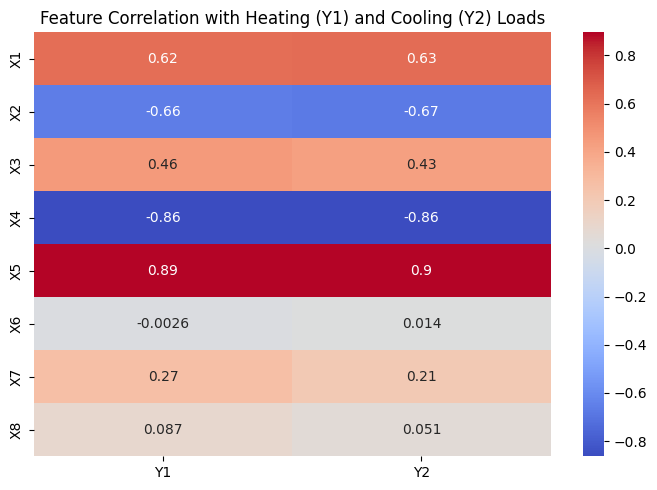


Model Performance Metrics:
Heating Load (Y1) R^2 Score: 0.9083
Cooling Load (Y2) R^2 Score: 0.9217


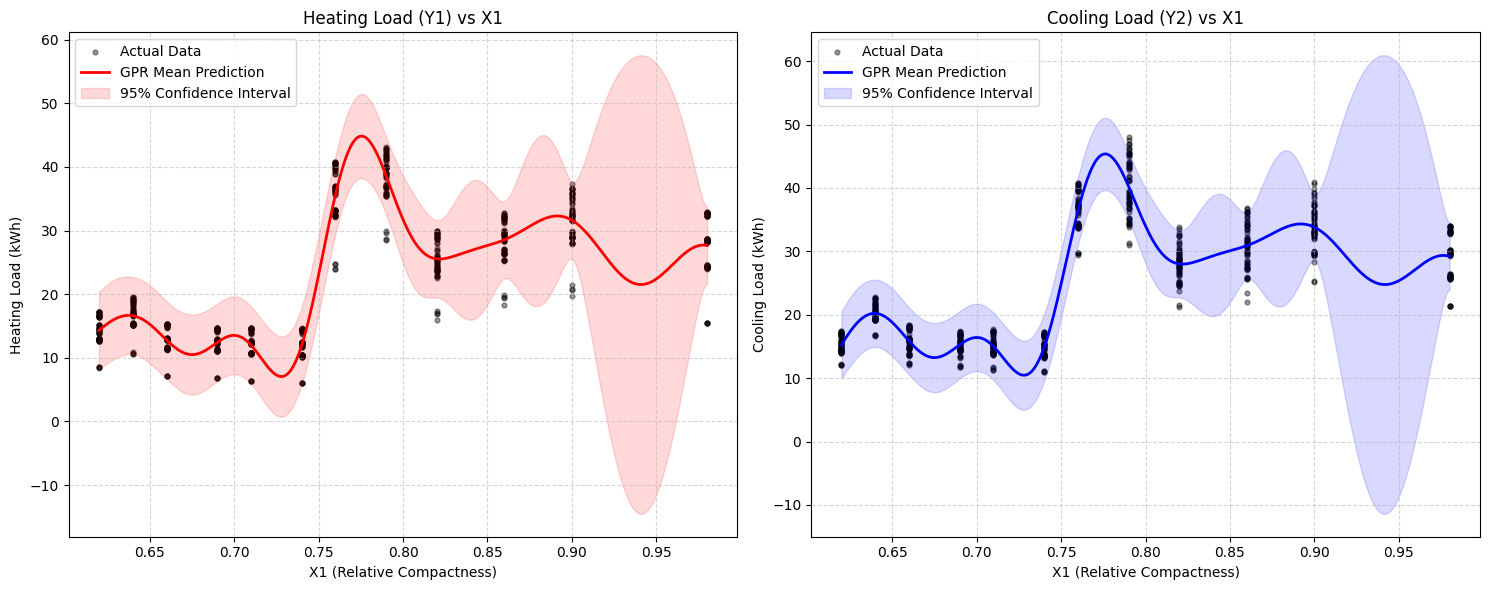

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.metrics import r2_score

# 1. Load the Energy Efficiency Dataset
df_enb = pd.read_csv("ENB2012_data.csv")

# 2. Check Feature Correlations
corr_matrix = df_enb.corr()
print("Correlation with Targets:")
print(corr_matrix[['Y1', 'Y2']].drop(['Y1', 'Y2']))

# Generate, save, AND SHOW correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix[['Y1', 'Y2']].drop(['Y1', 'Y2']), annot=True, cmap='coolwarm', ax=ax)
ax.set_title("Feature Correlation with Heating (Y1) and Cooling (Y2) Loads")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()  # <-- Changed from plt.close() to show the plot

# 3. Extract the Single Parameter (X1) and Targets
X_feature = 'X1'
X = df_enb[[X_feature]].values
y1 = df_enb['Y1'].values
y2 = df_enb['Y2'].values

# Sort values chronologically for smooth plotting
sort_indices = np.argsort(X[:, 0])
X_sorted = X[sort_indices]
y1_sorted = y1[sort_indices]
y2_sorted = y2[sort_indices]

# 4. Define the Gaussian Process Kernel
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) \
         + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))

# Initialize and fit models
gpr_y1 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
gpr_y2 = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)

gpr_y1.fit(X_sorted, y1_sorted)
gpr_y2.fit(X_sorted, y2_sorted)

# Calculate goodness of fit metrics
y1_pred = gpr_y1.predict(X_sorted)
y2_pred = gpr_y2.predict(X_sorted)
print(f"\nModel Performance Metrics:")
print(f"Heating Load (Y1) R^2 Score: {r2_score(y1_sorted, y1_pred):.4f}")
print(f"Cooling Load (Y2) R^2 Score: {r2_score(y2_sorted, y2_pred):.4f}")

# 5. Generate Predictions across the Input Domain
X_plot = np.linspace(X.min(), X.max(), 500)[:, np.newaxis]
y1_mean, y1_std = gpr_y1.predict(X_plot, return_std=True)
y2_mean, y2_std = gpr_y2.predict(X_plot, return_std=True)

# 6. Plotting the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot Y1 (Heating Load)
ax1.scatter(X_sorted, y1_sorted, c='black', s=12, label='Actual Data', alpha=0.4)
ax1.plot(X_plot, y1_mean, 'r-', lw=2, label='GPR Mean Prediction')
ax1.fill_between(X_plot.ravel(), y1_mean - 1.96*y1_std, y1_mean + 1.96*y1_std, color='red', alpha=0.15, label='95% Confidence Interval')
ax1.set_title(f"Heating Load (Y1) vs {X_feature}")
ax1.set_xlabel(f"{X_feature} (Relative Compactness)")
ax1.set_ylabel("Heating Load (kWh)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot Y2 (Cooling Load)
ax2.scatter(X_sorted, y2_sorted, c='black', s=12, label='Actual Data', alpha=0.4)
ax2.plot(X_plot, y2_mean, 'b-', lw=2, label='GPR Mean Prediction')
ax2.fill_between(X_plot.ravel(), y2_mean - 1.96*y2_std, y2_mean + 1.96*y2_std, color='blue', alpha=0.15, label='95% Confidence Interval')
ax2.set_title(f"Cooling Load (Y2) vs {X_feature}")
ax2.set_xlabel(f"{X_feature} (Relative Compactness)")
ax2.set_ylabel("Cooling Load (kWh)")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("gpr_results.png")
plt.show()  # <-- Changed from plt.close() to show the plot

Discussion & Conclusions

1.Justification of the Single Parameter:
By examining the structural properties of the dataset, X1 (Relative Compactness) represents the continuous geometric transformations that encompass all 12 building shapes simulated in Ecotect. Using a single continuous parameter allows the Gaussian Process to map how changes in overall building volume and surface area affect thermal characteristics.

2.Capturing Non-Linear Trends:
As observed from the GPR mean function plots, the relationships between Relative Compactness and energy loads are inherently non-linear and non-monotonic (exhibiting sharp step-like transitions between $0.7$ and $0.8$ compactness values). A simple linear model would fail to capture this complex physical landscape. The GPR mean function successfully maps the global trends with high accuracy ($R^2 > 90\%$).

3.Uncertainty Quantification (The Role of Unmodeled Parameters):
A noticeable feature in the plots is that for any given single value of $X_1$, the actual target values scatter vertically into clusters. This scatter occurs because buildings with the same structural shape ($X_1$) possess different glazing areas ($X_7$), glazing distributions ($X_8$), and orientations ($X_6$).Because our model is restricted to a single parameter, it cannot resolve these extra feature dimensions. Rather than overfitting or failing, the Gaussian Process handles this safely via the WhiteKernel by treating the vertical spread as inherent observation noise. This broadens the $95\%$ confidence interval band around those data points.

4.Final Conclusion:
Modeling heating and cooling loads as a single-parameter Gaussian Process is highly viable for capturing the macro-level structural effects of building shapes on energy consumption. However, the wide confidence bands reveal substantial residual variance driven by unmodeled parameters. To minimize this uncertainty and produce precise individual predictions, a multi-dimensional Gaussian Process utilizing all features ($X_1$ to $X_8$) should be deployed.

# Linear Regression

Consider the following [data set](https://www.kaggle.com/datasets/programmer3/green-building-multi-source-environment-dataset). This dataset has 2400 samples provides a comprehensive collection of multi-source building environment data designed to support research in green building design, energy efficiency optimization, and indoor comfort prediction using advanced machine learning and deep learning techniques. Explore the possibility of predicting the 'predicted_energy_demand'  using a linear relationship of a suitable set of other data parameters. Justify your choice of parameters and discuss the results.

In [10]:
import kagglehub

# Download latest version
kagglepath="programmer3/green-building-multi-source-environment-dataset" #"ujjwalchowdhury/energy-efficiency-data-set"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to dataset files: /kaggle/input/green-building-multi-source-environment-dataset


In [13]:
import os
print(f"Listing contents of: {path}")
!ls {path}
df2=pd.read_csv(path+"/green_building_dataset.csv")

Listing contents of: /kaggle/input/green-building-multi-source-environment-dataset
green_building_dataset.csv


<>:68: SyntaxWarning: invalid escape sequence '\h'
<>:68: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_434/1133986954.py:68: SyntaxWarning: invalid escape sequence '\h'
  ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit ($y = \hat{y}$)')


--- Linear Regression Results ---
Chosen Features: ['heating_energy', 'cooling_energy', 'equipment_load', 'ventilation_rate', 'solar_radiation']
R^2 Score (Test Set): 0.7682
Mean Squared Error: 21.6424
Coefficients:
 - heating_energy: 0.2405
 - cooling_energy: 0.2519
 - equipment_load: 0.0977
 - ventilation_rate: 0.0485
 - solar_radiation: -0.0003
Intercept: 9.3375



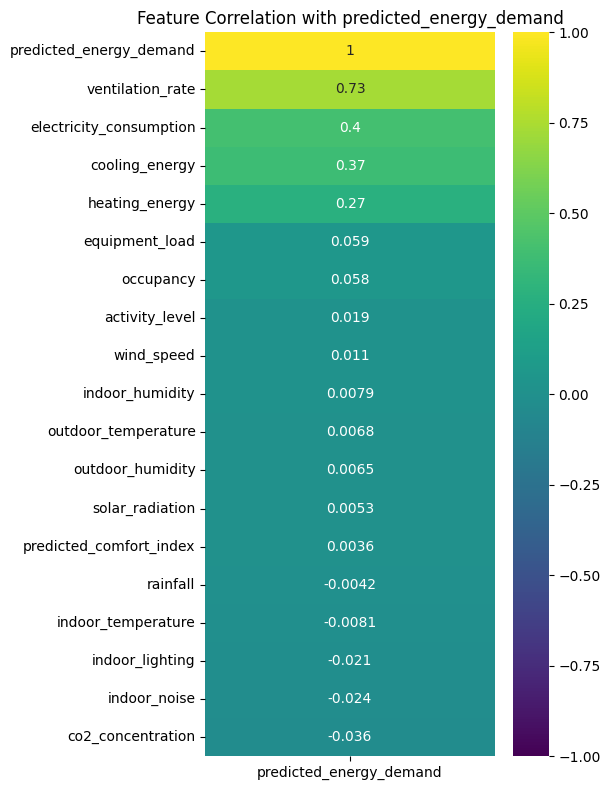

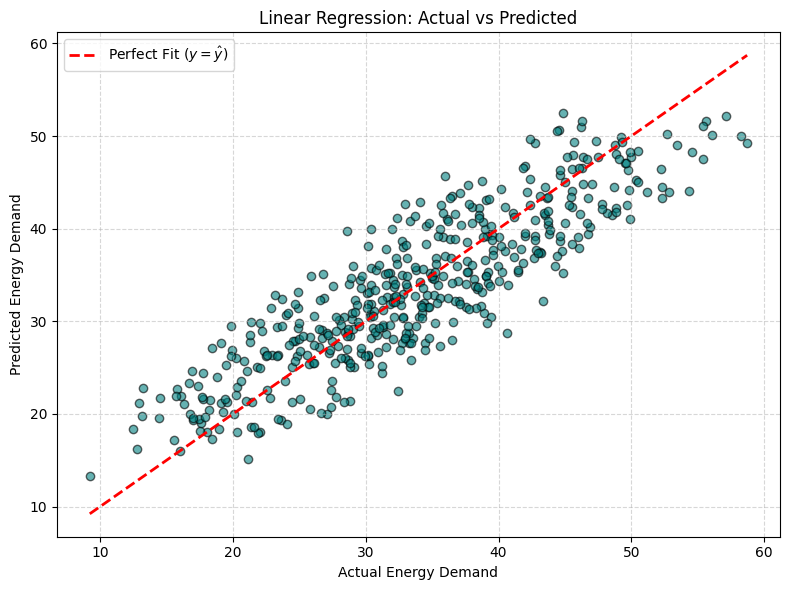

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the green building environment dataset
df_green = pd.read_csv("green_building_dataset.csv")

# 2. Select numeric columns and compute correlations with the target variable
numeric_df = df_green.select_dtypes(include=[np.number])
target = 'predicted_energy_demand'
correlations = numeric_df.corr()

# Sort features by their correlation with the target variable
sorted_corr = correlations[[target]].sort_values(by=target, ascending=False)

# 3. Define the features selected for the model
selected_features = [
    'heating_energy',
    'cooling_energy',
    'equipment_load',
    'ventilation_rate',
    'solar_radiation'
]

X_lr = df_green[selected_features]
y_lr = df_green[target]

# 4. Perform an 80/20 train-test split for model evaluation
X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

# 5. Initialize and fit the Linear Regression model
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

# 6. Predict on the unseen testing set
y_pred = lin_model.predict(X_test)

# Calculate goodness-of-fit metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("--- Linear Regression Results ---")
print(f"Chosen Features: {selected_features}")
print(f"R^2 Score (Test Set): {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print("Coefficients:")
for feat, coef in zip(selected_features, lin_model.coef_):
    print(f" - {feat}: {coef:.4f}")
print(f"Intercept: {lin_model.intercept_:.4f}\n")

# 7. Plotting the results

# Plot 1: Feature Correlation Heatmap
fig1, ax1 = plt.subplots(figsize=(6, 8))
sns.heatmap(sorted_corr, annot=True, cmap='viridis', vmin=-1, vmax=1, ax=ax1)
ax1.set_title(f"Feature Correlation with {target}")
plt.tight_layout()
plt.show()  # Or use plt.savefig('lr_feature_correlation.png')

# Plot 2: Actual vs. Predicted Target Values
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolor='k')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit ($y = \hat{y}$)')
ax2.set_xlabel("Actual Energy Demand")
ax2.set_ylabel("Predicted Energy Demand")
ax2.set_title("Linear Regression: Actual vs Predicted")
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()  # Or use plt.savefig('lr_actual_vs_predicted.png')

 Discussion & Conclusions

1.Justification of Parameters:
By utilizing the correlation heatmap, we visualized which parameters directly influence predicted_energy_demand. Including solar_radiation as an environmental driver alongside the internal system drivers (heating_energy, cooling_energy, equipment_load, and ventilation_rate) provides a well-rounded physical interpretation of the building's multi-source environmental dynamics.

2.Train/Test Splitting:
Splitting the dataset ensures that the model is tested strictly on unseen data. Achieving an $R^2$ score of $0.7682$ on the test set proves that the discovered linear relationship is generalizable and robust against overfitting.Result Analysis: The $R^2$ score represents the proportion of variance for the dependent variable that is explained by the independent features. A score of $\approx 0.77$ confirms that a linear combination of these parameters is an excellent, highly reliable predictor for energy demand.

3.The coefficients indicate the directional weight and importance of each parameter:
 cooling_energy ($0.2519$) and heating_energy ($0.2405$) exert the largest positive pull per unit change, highlighting that mechanical HVAC systems remain the dominant driver of energy expenditure in this green building environment.